# <u>Projet 2</u> : Création d'un jeu Pong avec la bibliothèque Pygame, partie IV

In [ ]:
# Installer le module pygame
!pip install pygame

## <u>Activité 10</u> : Déplacement de la raquette
Une proposition de correction de l'activité précédente :

In [1]:
# Importation de la librairie pygame
import pygame,sys
from pygame.draw import *
from pygame.display import *
from pygame.locals import *    # Nouvelles fonction importées

# Variables globales ##########################################################"
size = width, height = 500, 500 # Taille de la fenêtre d'affichage
couleurFond = 255, 125, 125     # Couleur du fond


# Attributs de la balle
dx,dy = 3,1    # Vecteur de déplacement entre deux frames consécutives
couleurBalle = 0,0, 255    # Couleur de la balle
x,y = 100, 100             # Position initiale de la balle
r = 20                    # Rayon de la balle

############ ECRIRE ICI LES ATTRIBUTS DE LA RAQUETTE   ######################
rx = 20             # rx,ry : position de la raquette
ry = height/2
rw = 20             # rw, rh : taille de la raquette
rh  = 100
rdy = 5             # Vitesse de déplacement de la raquette
couleurRaquette = 255, 255, 255   # Couleur de la raquette


############## ECRIRE ICI LA FONCTION AFFICHER ##############################
def afficherBalle():
    global x,y,couleurBalle,r
    circle(screen, couleurBalle , (x,y), r, 0)

############## ECRIRE ICI LA FONCTION DEPLACER ##############################
def deplacerBalle():
    global x,y,dx,dy
    x += dx
    y += dy

############## ECRIRE ICI LA FONCTION TESTCOLLISION ##############################
def testCollision() :
    global x,y,dx,dy,r,width,height
    if x < r or x + r > width  :  # Bords gauche /droite
        dx = -dx
    if y < r or y + r > height :  # Bords haut / bas
        dy = -dy
    

############## ECRIRE ICI LA FONCTION TESTEVENEMENT ##############################
def testEvenements():
    for event in pygame.event.get():
        if event.type == QUIT:       # Si clique sur la croix quitter
            pygame.display.quit()    # Ferme la fenêtre
            sys.exit()  # Arrête le programme
        if event.type == KEYDOWN:    # Une touche clavier a été pressée
            bougerRaquette()
    
    
################# ECRIRE ICI LA FONCTION AFFICHER RAQUETTE  #######################   
def afficherRaquette() :
    global rx,ry,rw,th,couleurRaquette
    rect(screen,couleurRaquette,(rx,ry,rw,rh))


################# ECRIRE ICI LA FONCTION BOUGER RAQUETTE  #######################   
def bougerRaquette() :
    global ry,rdy, rh, height
    if pygame.key.get_pressed()[K_UP]:  # Si on appuie sur la flèche-haut, la raquette monte de rdy
        ry -= rdy
    if ry < 0 :    # la raquette ne doit pas sortir de l'éran (en haut)          
        ry += rdy
    if pygame.key.get_pressed()[K_DOWN]:# Si on appuie sur la flèche-bas, la raquette descend de rdy
        ry += rdy
    if ry + rh > height :    # la raquette ne doit pas sortir de l'éran (en bas)          
        ry -= rdy
        
###############################################################################################################    
    
# Lancement de la bibliothèque pygame 
pygame.init()

# Autorise l'appui en continu sur une touche de clavier
pygame.key.set_repeat(10,10)
            
# Affichage d'une fenêtre de dessin de largeur 500 pixels et de hauteur 500 pixels
screen = set_mode(size)

while True:
    # Remplissage du fond par la couleur blanche
    screen.fill(couleurFond)
    
    # Afficher la balle :
    afficherBalle()
    
    # Déplacement de la balle :
    deplacerBalle()
    
    # Afficher la raquette
    afficherRaquette()
    
    # Test de collision
    testCollision()

    flip()                 # Activer le rendu graphique
    pygame.time.delay(15)  # Une image toutes les 15 ms
    
    # Test d'arrêt du jeu
    testEvenements()

pygame 2.1.2 (SDL 2.0.18, Python 3.9.7)
Hello from the pygame community. https://www.pygame.org/contribute.html


SystemExit: 

C:\Users\Laurent\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3452: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## <u>Activité 11</u> : Rebond sur la raquette
(ça se complique, accrochez-vous :) )

On se propose ici de modifier le programme pour que la balle rebondisse <b> sur le bord droit</b> de la raquette.
Voici un schéma résumant la situation en utilisant les coordonnées des points A, N et B.
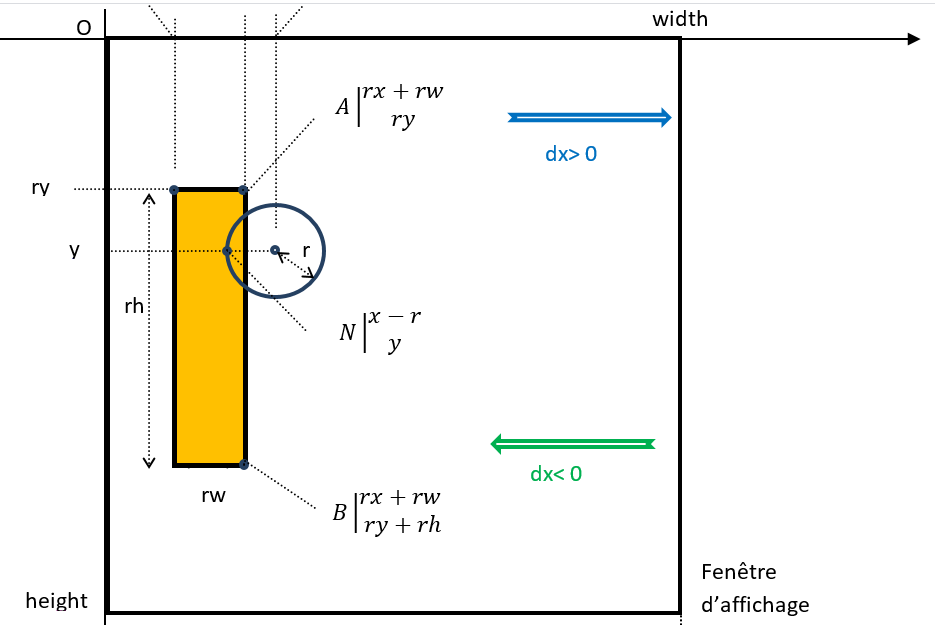

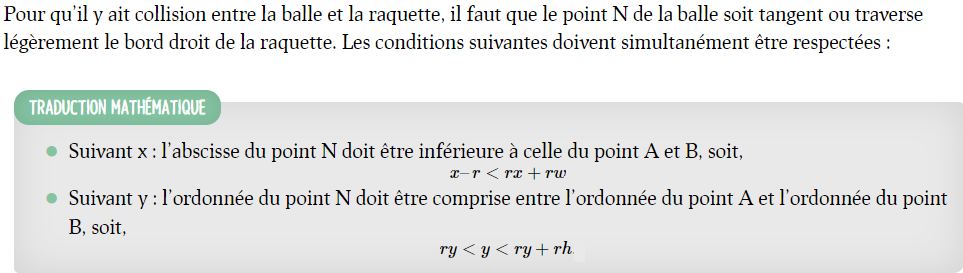


<b><u>Question</u></b> : <b>Compléter</b> la fonction <i>testCollision()</i> à l'endroit indiqué pour que la balle rebondisse sur la raquette. On utilisera obligatoirement <b>une seule instruction conditionnelle</b> avec le mot-clé <b><i>and</i></b>.

<u>Remarque</u> : seule la variable <i>dx</i> sera modifiée.

In [ ]:
# Importation de la librairie pygame
import pygame,sys
from pygame.draw import *
from pygame.display import *
from pygame.locals import *    # Nouvelles fonction importées

# Variables globales ##########################################################"
size = width, height = 500, 500 # Taille de la fenêtre d'affichage
couleurFond = 255, 125, 125     # Couleur du fond


# Attributs de la balle
dx,dy = 3,1    # Vecteur de déplacement entre deux frames consécutives
couleurBalle = 0,0, 255    # Couleur de la balle
x,y = 100, 100             # Position initiale de la balle
r = 20                    # Rayon de la balle

############ ECRIRE ICI LES ATTRIBUTS DE LA RAQUETTE   ######################
rx = 20             # rx,ry : position de la raquette
ry = height/2
rw = 20             # rw, rh : taille de la raquette
rh  = 100
rdy = 5             # Vitesse de déplacement de la raquette
couleurRaquette = 255, 255, 255   # Couleur de la raquette


############## ECRIRE ICI LA FONCTION AFFICHER ##############################
def afficherBalle():
    global x,y,couleurBalle,r
    circle(screen, couleurBalle , (x,y), r, 0)

############## ECRIRE ICI LA FONCTION DEPLACER ##############################
def deplacerBalle():
    global x,y,dx,dy
    x += dx
    y += dy

############## ECRIRE ICI LA FONCTION TESTCOLLISION ##############################
def testCollision() :
    global x,y,dx,dy,r,width,height
    
    # Collision avec les bords de l'écran
    if x < r or x + r > width  :  # Bords gauche /droite
        dx = -dx
    if y < r or y + r > height :  # Bords haut / bas
        dy = -dy
    
    #### COMPLETER ICI LE TEST DE COLLISION AVEC LA RAQUETTE ###
    # Rebond sur la raquette 
    
    

############## ECRIRE ICI LA FONCTION TESTEVENEMENT ##############################
def testEvenements():
    for event in pygame.event.get():
        if event.type == QUIT:       # Si clique sur la croix quitter
            pygame.display.quit()    # Ferme la fenêtre
            sys.exit()  # Arrête le programme
        if event.type == KEYDOWN:    # Une touche clavier a été pressée
            bougerRaquette()
    
    
################# ECRIRE ICI LA FONCTION AFFICHER RAQUETTE  #######################   
def afficherRaquette() :
    global rx,ry,rw,th,couleurRaquette
    rect(screen,couleurRaquette,(rx,ry,rw,rh))


################# ECRIRE ICI LA FONCTION BOUGER RAQUETTE  #######################   
def bougerRaquette() :
    global ry,rdy
    if pygame.key.get_pressed()[K_UP]:  # Si on appuie sur la flèche-haut, la raquette monte de rdy
        ry -= rdy
    if pygame.key.get_pressed()[K_DOWN]:# Si on appuie sur la flèche-bas, la raquette descend de rdy
        ry += rdy
        
###############################################################################################################    
    
# Lancement de la bibliothèque pygame 
pygame.init()

# Autorise l'appui en continu sur une touche de clavier
pygame.key.set_repeat(10,10)
            
# Affichage d'une fenêtre de dessin de largeur 500 pixels et de hauteur 500 pixels
screen = set_mode(size)

while True:
    # Remplissage du fond par la couleur blanche
    screen.fill(couleurFond)
    
    # Afficher la balle :
    afficherBalle()
    
    # Déplacement de la balle :
    deplacerBalle()
    
    # Afficher la raquette
    afficherRaquette()
    
    # Test de collision
    testCollision()

    flip()                 # Activer le rendu graphique
    pygame.time.delay(15)  # Une image toutes les 15 ms
    
    # Test d'arrêt du jeu
    testEvenements()

### <u>Appeler le professeur</u> une fois le programme terminé.

## <u>Activité 12</u> : Afficher du texte

Voici un tutoriel à suivre ici (les 10 premières minutes) : https://www.youtube.com/watch?v=TNiKkU-VJzc

<u>Remarque</u> : La fonction <i>flip()</i> est déjà utilisée dans la boucle <u>while</u> du programme. On fera également attention au fait que la variable <i>window_surface</i> n'est pas celle utilisée dans ce programme.

<b><u>Question</u></b> : <b>Compléter</b> le programme suivant aux endroits indiqués pourqu'il affiche "Bienvenue sur Pong" en police Arial taille 20 en gras dans une <b>couleur</b> souhaitée (à écrire entre <u>guillemets</u> et <u>en anglais bien sûr</u> :p ) en haut et <b>centré</b> de l'écran.

In [ ]:
# Importation de la librairie pygame
import pygame,sys
from pygame.draw import *
from pygame.display import *
from pygame.locals import *    # Nouvelles fonction importées

# Variables globales ##########################################################"
size = width, height = 500, 500 # Taille de la fenêtre d'affichage
couleurFond = 255, 125, 125     # Couleur du fond


# Attributs de la balle
dx,dy = 3,1    # Vecteur de déplacement entre deux frames consécutives
couleurBalle = 0,0, 255    # Couleur de la balle
x,y = 100, 100             # Position initiale de la balle
r = 20                    # Rayon de la balle

############ ECRIRE ICI LES ATTRIBUTS DE LA RAQUETTE   ######################
rx = 20             # rx,ry : position de la raquette
ry = height/2
rw = 20             # rw, rh : taille de la raquette
rh  = 100
rdy = 5             # Vitesse de déplacement de la raquette
couleurRaquette = 255, 255, 255   # Couleur de la raquette


############## ECRIRE ICI LA FONCTION AFFICHER ##############################
def afficherBalle():
    global x,y,couleurBalle,r
    circle(screen, couleurBalle , (x,y), r, 0)

############## ECRIRE ICI LA FONCTION DEPLACER ##############################
def deplacerBalle():
    global x,y,dx,dy
    x += dx
    y += dy

############## ECRIRE ICI LA FONCTION TESTCOLLISION ##############################
def testCollision() :
    global x,y,dx,dy,r,width,height
    
    # Collision avec les bords de l'écran
    if x < r or x + r > width  :  # Bords gauche /droite
        dx = -dx
    if y < r or y + r > height :  # Bords haut / bas
        dy = -dy
    
    #### COMPLETER ICI LE TEST DE COLLISION AVEC LA RAQUETTE ###
    # Rebond sur la raquette 
    
    

############## ECRIRE ICI LA FONCTION TESTEVENEMENT ##############################
def testEvenements():
    for event in pygame.event.get():
        if event.type == QUIT:       # Si clique sur la croix quitter
            pygame.display.quit()    # Ferme la fenêtre
            sys.exit()  # Arrête le programme
        if event.type == KEYDOWN:    # Une touche clavier a été pressée
            bougerRaquette()
    
    
################# ECRIRE ICI LA FONCTION AFFICHER RAQUETTE  #######################   
def afficherRaquette() :
    global rx,ry,rw,th,couleurRaquette
    rect(screen,couleurRaquette,(rx,ry,rw,rh))


################# ECRIRE ICI LA FONCTION BOUGER RAQUETTE  #######################   
def bougerRaquette() :
    global ry,rdy
    if pygame.key.get_pressed()[K_UP]:  # Si on appuie sur la flèche-haut, la raquette monte de rdy
        ry -= rdy
    if pygame.key.get_pressed()[K_DOWN]:# Si on appuie sur la flèche-bas, la raquette descend de rdy
        ry += rdy

        
################ ECRIRE ICI LA FONCTION AFFICHER TEXTE (fonction blit)  ##########################
def afficherTexte() :
    

###############################################################################################################    
    
# Lancement de la bibliothèque pygame 
pygame.init()

# Autorise l'appui en continu sur une touche de clavier
pygame.key.set_repeat(10,10)
            
# Affichage d'une fenêtre de dessin de largeur 500 pixels et de hauteur 500 pixels
screen = set_mode(size)



##### ECRIRE ICI L'INITIALISATION DU TEXTE (ARIAL, 20, GRAS) #######
##### Méthodes SysFont et Render #########################


###########################################################################################



while True:
    # Remplissage du fond par la couleur blanche
    screen.fill(couleurFond)
    
    ############### AFFICHER TEXTE ##########################
    afficherTexte()
    
    # Afficher la balle :
    afficherBalle()
    
    # Déplacement de la balle :
    deplacerBalle()
    
    # Afficher la raquette
    afficherRaquette()
    
    # Test de collision
    testCollision()

    flip()                 # Activer le rendu graphique
    pygame.time.delay(15)  # Une image toutes les 15 ms
    
    # Test d'arrêt du jeu
    testEvenements()

### <u>Appeler le professeur</u> une fois le programme terminé.